In [52]:
# 1. Load the Data

import pandas as pd

myData = pd.read_csv("COVID-19_Dataset.csv")
myData.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,...,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,CLASIFFICATION_FINAL,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,...,2,2,1,2,2,2,2,2,3,97
1,2,1,2,1,03/06/2020,97,1,72,97,2,...,2,2,1,2,2,1,1,2,5,97
2,2,1,2,2,09/06/2020,1,2,55,97,1,...,2,2,2,2,2,2,2,2,3,2
3,2,1,1,1,12/06/2020,97,2,53,2,2,...,2,2,2,2,2,2,2,2,7,97
4,2,1,2,1,21/06/2020,97,2,68,97,1,...,2,2,1,2,2,2,2,2,3,97


In [53]:
myData.shape

(1048575, 21)

In [54]:
# 2a. Handling Medical Variables

medical_variables = [
    "DIABETES",
    "COPD",
    "ASTHMA",
    "INMSUPR",
    "HIPERTENSION",
    "CARDIOVASCULAR",
    "RENAL_CHRONIC",
    "OTHER_DISEASE",
    "OBESITY",
    "TOBACCO"
]

In [55]:
myData[medical_variables] = myData[medical_variables].replace([97, 99], pd.NA)
myData[medical_variables] = myData[medical_variables].fillna("Unknown")

In [56]:
myData[medical_variables].head()

,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,CARDIOVASCULAR,RENAL_CHRONIC,OTHER_DISEASE,OBESITY,TOBACCO
0,2,2,2,2,1,2,2,2,2,2
1,2,2,2,2,1,2,1,2,1,2
2,1,2,2,2,2,2,2,2,2,2
3,2,2,2,2,2,2,2,2,2,2
4,1,2,2,2,1,2,2,2,2,2


In [57]:
# 2b. Handling Demographic Variables

demo_variables = [
    "SEX",
    "PREGNANT"
]

In [58]:
myData[demo_variables] = myData[demo_variables].replace([97, 99], pd.NA)
myData[demo_variables] = myData[demo_variables].fillna("Unknown")

In [59]:
myData[demo_variables].head()

,SEX,PREGNANT
0,1,2
1,2,Unknown
2,2,Unknown
3,1,2
4,2,Unknown


In [60]:
# 2c. Handling Age Demographic Variable

myData["AGE"] = myData["AGE"].replace([97, 99], pd.NA)
myData["AGE"].isna().sum()

221

In [61]:
myData = myData.dropna(subset = ["AGE"])

In [62]:
myData.shape

(1048354, 21)

In [63]:
# 3. Filtering COVID-Positive Patients

myData = myData[myData["CLASIFFICATION_FINAL"].isin([1, 2, 3])]
myData = myData.drop(columns = ["CLASIFFICATION_FINAL"])

In [64]:
myData.shape

(391904, 20)

In [65]:
myData.head()

,USMER,MEDICAL_UNIT,SEX,PATIENT_TYPE,DATE_DIED,INTUBED,PNEUMONIA,AGE,PREGNANT,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,OTHER_DISEASE,CARDIOVASCULAR,OBESITY,RENAL_CHRONIC,TOBACCO,ICU
0,2,1,1,1,03/05/2020,97,1,65,2,2,2,2,2,1,2,2,2,2,2,97
2,2,1,2,2,09/06/2020,1,2,55,Unknown,1,2,2,2,2,2,2,2,2,2,2
4,2,1,2,1,21/06/2020,97,2,68,Unknown,1,2,2,2,1,2,2,2,2,2,97
5,2,1,1,2,9999-99-99,2,1,40,2,2,2,2,2,2,2,2,2,2,2,2
6,2,1,1,1,9999-99-99,97,2,64,2,2,2,2,2,2,2,2,2,2,2,97


In [66]:
# 4. Creating the Death Variable and Dropping Leakage Variables

myData["DEATH"] = (myData["DATE_DIED"] != "9999-99-99").astype(int)
myData = myData.drop(columns = ["DATE_DIED", "INTUBED", "ICU", "PATIENT_TYPE", "PNEUMONIA", "USMER", "MEDICAL_UNIT"])

In [67]:
# 5. Predictors

target = "DEATH"

predictors = [
    # Medical Variables
    "DIABETES",
    "COPD",
    "ASTHMA",
    "INMSUPR",
    "HIPERTENSION",
    "CARDIOVASCULAR",
    "RENAL_CHRONIC",
    "OTHER_DISEASE",
    "OBESITY",
    "TOBACCO",
    # Demographic Variables
    "SEX",
    "PREGNANT",
    "AGE"
]

In [68]:
pre_model = myData[predictors + [target]]
pre_model.isna().sum()

DIABETES          0
COPD              0
ASTHMA            0
INMSUPR           0
HIPERTENSION      0
CARDIOVASCULAR    0
RENAL_CHRONIC     0
OTHER_DISEASE     0
OBESITY           0
TOBACCO           0
SEX               0
PREGNANT          0
AGE               0
DEATH             0
dtype: int64

In [69]:
pre_model["AGE"] = pd.to_numeric(pre_model["AGE"], errors = "coerce")
pre_model = pre_model.dropna(subset = ["AGE"])

In [70]:
pre_model.head(10)

,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,CARDIOVASCULAR,RENAL_CHRONIC,OTHER_DISEASE,OBESITY,TOBACCO,SEX,PREGNANT,AGE,DEATH
0,2,2,2,2,1,2,2,2,2,2,1,2,65,1
2,1,2,2,2,2,2,2,2,2,2,2,Unknown,55,1
4,1,2,2,2,1,2,2,2,2,2,2,Unknown,68,1
5,2,2,2,2,2,2,2,2,2,2,1,2,40,0
6,2,2,2,2,2,2,2,2,2,2,1,2,64,0
7,1,2,2,1,1,2,1,2,2,2,1,2,64,0
8,1,2,2,2,1,2,2,2,1,2,1,2,37,0
9,2,2,2,2,2,2,2,2,2,2,1,2,25,0
10,2,2,2,2,2,2,2,2,2,2,1,2,38,0
11,2,2,2,2,2,2,2,2,2,2,2,Unknown,24,0


In [71]:
# 6. Encoding Categorical Variables

x = pre_model.drop(columns = ["DEATH"])
y = pre_model["DEATH"]

In [72]:
numeric_variable = ["AGE"]

categorical_variables = [
    "SEX",
    "PREGNANT",
    "DIABETES",
    "COPD",
    "ASTHMA",
    "INMSUPR",
    "HIPERTENSION",
    "CARDIOVASCULAR",
    "RENAL_CHRONIC",
    "OTHER_DISEASE",
    "OBESITY",
    "TOBACCO"
]

In [73]:
x_cat = pd.get_dummies(
    x[categorical_variables],
    drop_first = True
)

In [74]:
model_data = pd.concat(
    [x[numeric_variable], x_cat],
    axis = 1
)

In [75]:
model_data.shape

(391904, 15)

In [76]:
model_data.head()

,AGE,SEX,DIABETES,COPD,ASTHMA,INMSUPR,HIPERTENSION,CARDIOVASCULAR,RENAL_CHRONIC,OTHER_DISEASE,OBESITY,TOBACCO,PREGNANT_2,PREGNANT_98,PREGNANT_Unknown
0,65,1,2,2,2,2,1,2,2,2,2,2,True,False,False
2,55,2,1,2,2,2,2,2,2,2,2,2,False,False,True
4,68,2,1,2,2,2,1,2,2,2,2,2,False,False,True
5,40,1,2,2,2,2,2,2,2,2,2,2,True,False,False
6,64,1,2,2,2,2,2,2,2,2,2,2,True,False,False


In [77]:
# 7. Cross Validation

df_model = model_data.copy()
df_model["DEATH"] = y.values

In [78]:
TData = (df_model.groupby("DEATH", group_keys = False).apply(lambda d: d.sample(
    frac = 0.8, 
    random_state = 42)
    ))
VData = df_model.drop(TData.index)

In [79]:
x_train = TData.drop(columns = ["DEATH"])
y_train = TData["DEATH"]

constant_cols = [c for c in x_train.columns if x_train[c].nunique() <= 1]
x_train = x_train.drop(columns = constant_cols)

x_val = VData.drop(columns = ["DEATH"]).drop(columns = constant_cols, errors = "ignore")
x_val = x_val.reindex(columns=x_train.columns, fill_value=0)
y_val = VData["DEATH"]

In [80]:
# 8. Fit Logistic Regression

import statsmodels.formula.api as smf

predictor_cols = x_train.columns.tolist()
formula = "DEATH ~ " + " + ".join(predictor_cols)

logit_model = smf.logit(formula = formula, data = TData).fit_regularized(alpha = 1.0)

C:\Users\wasay\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2383: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
C:\Users\wasay\anaconda3\Lib\site-packages\statsmodels\discrete\discrete_model.py:2441: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


Optimization terminated successfully    (Exit mode 0)
            Current function value: 0.3159133356263133
            Iterations: 199
            Function evaluations: 210
            Gradient evaluations: 199


C:\Users\wasay\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:71: ConvergenceWarning: QC check did not pass for 7 out of 16 parameters
Try increasing solver accuracy or number of iterations, decreasing alpha, or switch solvers
  warnings.warn(message, ConvergenceWarning)
C:\Users\wasay\anaconda3\Lib\site-packages\statsmodels\base\l1_solvers_common.py:144: ConvergenceWarning: Could not trim params automatically due to failed QC check. Trimming using trim_mode == 'size' will still work.
  warnings.warn(msg, ConvergenceWarning)


In [81]:
logit_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  DEATH   No. Observations:               313523
Model:                          Logit   Df Residuals:                   313507
Method:                           MLE   Df Model:                           15
Date:                Sun, 28 Dec 2025   Pseudo R-squ.:                  0.2140
Time:                        00:25:01   Log-Likelihood:                -99034.
converged:                       True   LL-Null:                   -1.2599e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -4.3427   9.56e+04  -4.54e-05      1.000   -1.87e+05    1.87e+05
PREGNANT_2[T.True]          -0.0519      0.149     -0.348      0.728      -0.344       0.240
PREGNANT_98[T.True]         -1.2412      0.231     -5.381      0.000      -1.693      -0.789
PREGNANT_Unknown[T.True]     2.4099   9.56e+04   2.52e-05      1.000   -1.87e+05    1.87e+05
AGE                          0.0785      0.000    194.523      0.000       0.078       0.079
SEX                         -1.8834   9.56e+04  -1.97e-05      1.000   -1.87e+05    1.87e+05
DIABETES                    -0.0113      0.002     -5.508      0.000      -0.015      -0.007
COPD                         0.0065      0.003      2.530      0.011       0.001       0.012
ASTHMA                       0.0101      0.003      3.761      0.000       0.005       0.015
INMSUPR                      0.0013      0.002      0.595      0.552      -0.003       0.006
HIPERTENSION                -0.0056      0.002     -2.318      0.020      -0.010      -0.001
CARDIOVASCULAR               0.0108      0.002      4.703      0.000       0.006       0.015
RENAL_CHRONIC               -0.0102      0.003     -3.791      0.000      -0.015      -0.005
OTHER_DISEASE                0.0024      0.001      2.161      0.031       0.000       0.005
OBESITY                     -0.0003      0.002     -0.167      0.868      -0.004       0.003
TOBACCO                      0.0055      0.002      2.967      0.003       0.002       0.009
============================================================================================
"""

In [82]:
# 9. Prediction on Validation Set

val_probs = logit_model.predict(VData)

In [83]:
threshold = 0.5
val_pred = (val_probs >= threshold).astype(int)

In [84]:
# 10. Confusion Matrix

matrix = pd.crosstab(VData["DEATH"], val_pred, rownames = ["Actual"], colnames = ["Predicted"])
matrix

Predicted,0,1
Actual,,
0,65860,1681
1,8867,1973


In [85]:
# 11. Accuracy, Recall, Precision for more Thresholds

thresholds = [0.3, 0.4, 0.5, 0.6]

results = []
for t in thresholds:
    pred = (val_probs >= t).astype(int)
    tp = ((pred == 1) & (VData["DEATH"] == 1)).sum()
    fp = ((pred == 1) & (VData["DEATH"] == 0)).sum()
    fn = ((pred == 0) & (VData["DEATH"] == 1)).sum()
    tn = ((pred == 0) & (VData["DEATH"] == 0)).sum()

    acc = (pred == VData["DEATH"]).mean()
    rec = tp / (tp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0

    results.append([t, acc, rec, prec])

pd.DataFrame(results, columns = ["Threshold", "Accuracy", "Recall", "Precision"])

,Threshold,Accuracy,Recall,Precision
0,0.3,0.849390,0.449723,0.454970
1,0.4,0.862735,0.296771,0.506375
2,0.5,0.865427,0.182011,0.539956
3,0.6,0.864942,0.098708,0.567338


In [86]:
# 12. Interpreting the Model (Odds Ratio)

import numpy as np

summary_table = pd.DataFrame({
    "coef": logit_model.params,
    "odds_ratio": np.exp(logit_model.params),
    "p_value": logit_model.pvalues
}).sort_values("odds_ratio", ascending = False)

summary_table.head(15)

,coef,odds_ratio,p_value
PREGNANT_Unknown[T.True],2.409879,11.132612,9.999799e-01
AGE,0.078545,1.081712,0.000000e+00
CARDIOVASCULAR,0.010782,1.010840,2.568528e-06
ASTHMA,0.010110,1.010161,1.693246e-04
COPD,0.006502,1.006523,1.141488e-02
TOBACCO,0.005491,1.005506,3.007290e-03
OTHER_DISEASE,0.002429,1.002432,3.067750e-02
INMSUPR,0.001328,1.001329,5.521343e-01
OBESITY,-0.000286,0.999714,8.675636e-01
HIPERTENSION,-0.005551,0.994464,2.042688e-02


In [87]:
# 13. Plot ROC curve + AUC

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

auc = roc_auc_score(VData["DEATH"], val_probs)
fpr, tpr, _ = roc_curve(VData["DEATH"], val_probs)

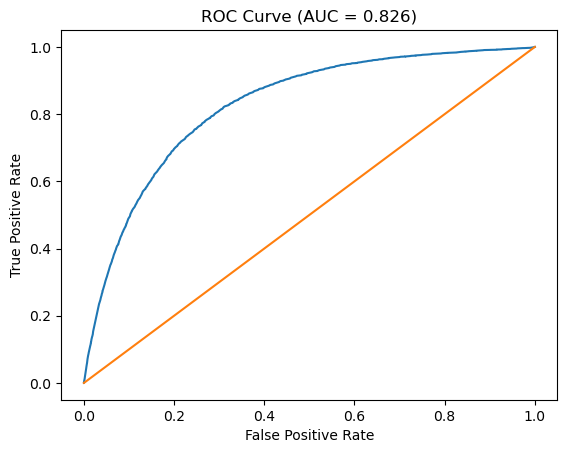

AUC: 0.8259511080900921


In [88]:
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {auc:.3f})")
plt.show()

print("AUC: " + str(auc))